<a href="https://colab.research.google.com/github/salahtarek404/5/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Import Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Data Collection

In [2]:
import requests
import pandas as pd

lat = 30.0444
lon = 31.2357
start = "2018-01-01"
end = "2026-04-01"

aq_params = "pm10,pm2_5,nitrogen_dioxide"
weather_params = "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation"

aq_url = f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude={lat}&longitude={lon}&hourly={aq_params}&start_date={start}&end_date={end}&timezone=Africa/Cairo"
weather_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&hourly={weather_params}&timezone=Africa/Cairo"

print("Fetching essential data from APIs (Cairo Timezone)...")

aq_res = requests.get(aq_url).json()
w_res = requests.get(weather_url).json()

df_aq = pd.DataFrame(aq_res['hourly'])
df_w = pd.DataFrame(w_res['hourly'])

df = pd.merge(df_aq, df_w, on="time")

df.to_csv("cairo_clean_data.csv", index=False)
print("Done! Data is now aligned with Cairo local time.")
print(df.head())

Fetching essential data from APIs (Cairo Timezone)...
Done! Data is now aligned with Cairo local time.
               time  pm10  pm2_5  nitrogen_dioxide  temperature_2m  \
0  2018-01-01T00:00  54.2   12.4               1.8            11.8   
1  2018-01-01T01:00  46.5   11.6               1.9            11.4   
2  2018-01-01T02:00  34.6    8.4               1.6            11.6   
3  2018-01-01T03:00  28.8   26.7               2.3            11.9   
4  2018-01-01T04:00  48.8   44.8              11.6            11.7   

   relative_humidity_2m  wind_speed_10m  precipitation  
0                    63            15.5            0.0  
1                    63            15.7            0.0  
2                    61            16.1            0.0  
3                    62            18.2            0.0  
4                    68            18.1            0.0  


In [3]:
len(df)

72312

# Data Preprocessing & Cleaning

In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (72312, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72312 entries, 0 to 72311
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  72312 non-null  object 
 1   pm10                  72312 non-null  float64
 2   pm2_5                 72312 non-null  float64
 3   nitrogen_dioxide      72312 non-null  float64
 4   temperature_2m        72312 non-null  float64
 5   relative_humidity_2m  72312 non-null  int64  
 6   wind_speed_10m        72312 non-null  float64
 7   precipitation         72312 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 4.4+ MB


In [5]:
df.isnull().sum()

,0
time,0
pm10,0
pm2_5,0
nitrogen_dioxide,0
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
precipitation,0


In [6]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


# Feature Engineering

In [7]:
# Create Target: AQI Classification based on PM2.5 (Standard EPA thresholds)
def get_aqi_class(pm25):
    if pm25 <= 12.0:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    else:
        return "Poor"

df['AQI_Class'] = df['pm2_5'].apply(get_aqi_class)

print("Class counts:")
print(df['AQI_Class'].value_counts())

Class counts:
AQI_Class
Moderate    52795
Poor        17162
Good         2355
Name: count, dtype: int64


In [8]:
df.head()


,time,pm10,pm2_5,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class
0,2018-01-01T00:00,54.2,12.4,1.8,11.8,63,15.5,0.0,Moderate
1,2018-01-01T01:00,46.5,11.6,1.9,11.4,63,15.7,0.0,Good
2,2018-01-01T02:00,34.6,8.4,1.6,11.6,61,16.1,0.0,Good
3,2018-01-01T03:00,28.8,26.7,2.3,11.9,62,18.2,0.0,Moderate
4,2018-01-01T04:00,48.8,44.8,11.6,11.7,68,18.1,0.0,Poor


In [9]:
df["AQI_Class"].value_counts()

,count
AQI_Class,
Moderate,52795
Poor,17162
Good,2355


In [10]:
# 1. Convert time column to datetime objects (if not already done)
df['time'] = pd.to_datetime(df['time'])

# 2. Extract specific features
df['year'] = df['time'].dt.year
df['day_of_week'] = df['time'].dt.dayofweek # For Modeling (0=Monday, 6=Sunday)

# 3. Create a Weekend flag (Useful for Cairo traffic patterns)
# 4 is Friday, 5 is Saturday in Egypt
df['is_weekend'] = df['day_of_week'].isin([4, 5]).astype(int)

# 4. Check the result
print(df[['time', 'day_of_week', 'is_weekend']].head())

                 time  day_of_week  is_weekend
0 2018-01-01 00:00:00            0           0
1 2018-01-01 01:00:00            0           0
2 2018-01-01 02:00:00            0           0
3 2018-01-01 03:00:00            0           0
4 2018-01-01 04:00:00            0           0


In [11]:
df.head()

,time,pm10,pm2_5,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class,year,day_of_week,is_weekend
0,2018-01-01 00:00:00,54.2,12.4,1.8,11.8,63,15.5,0.0,Moderate,2018,0,0
1,2018-01-01 01:00:00,46.5,11.6,1.9,11.4,63,15.7,0.0,Good,2018,0,0
2,2018-01-01 02:00:00,34.6,8.4,1.6,11.6,61,16.1,0.0,Good,2018,0,0
3,2018-01-01 03:00:00,28.8,26.7,2.3,11.9,62,18.2,0.0,Moderate,2018,0,0
4,2018-01-01 04:00:00,48.8,44.8,11.6,11.7,68,18.1,0.0,Poor,2018,0,0


# EDA


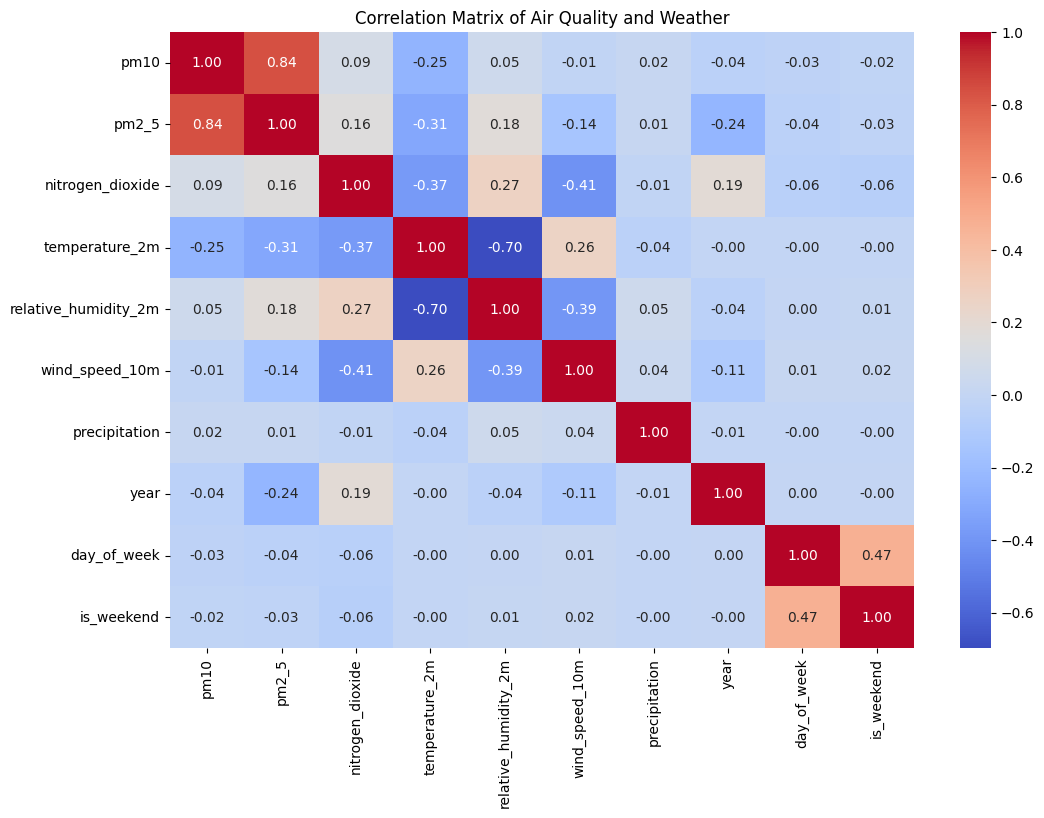

In [12]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Air Quality and Weather')
plt.show()

/tmp/ipykernel_1424/3449003614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_weekend', y='pm2_5', data=df, palette='Set2')


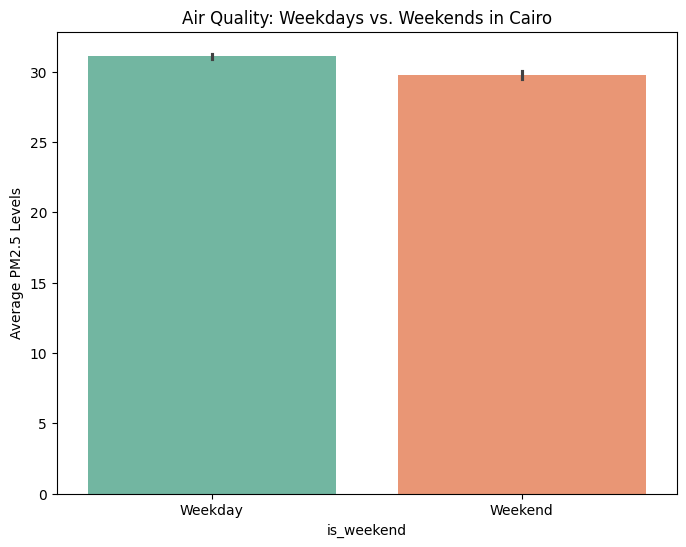

In [13]:
plt.figure(figsize=(8, 6))
sns.barplot(x='is_weekend', y='pm2_5', data=df, palette='Set2')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Air Quality: Weekdays vs. Weekends in Cairo')
plt.ylabel('Average PM2.5 Levels')
plt.show()

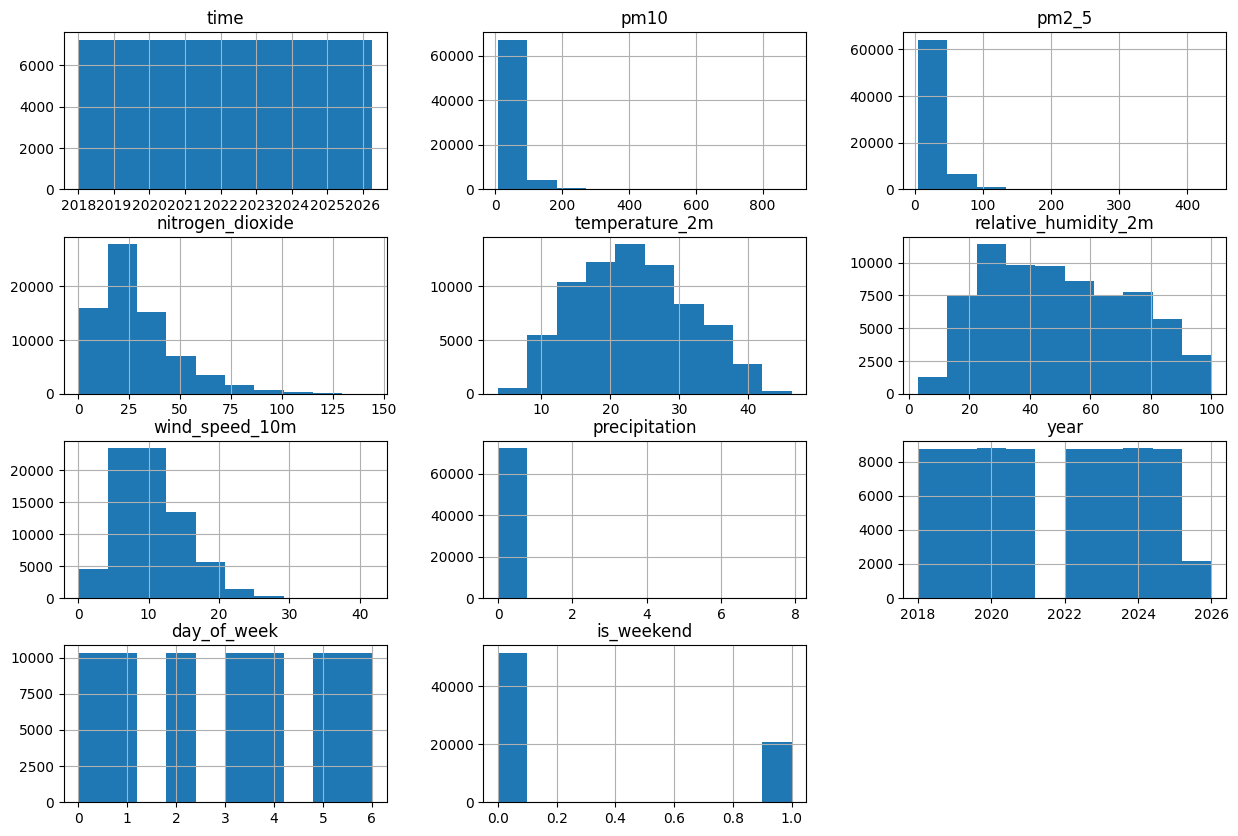

In [14]:
df.hist(figsize=(15,10))
plt.show()

/tmp/ipykernel_1424/2984946319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AQI_Class', data=df, palette='viridis', order=['Good', 'Moderate', 'Poor'])


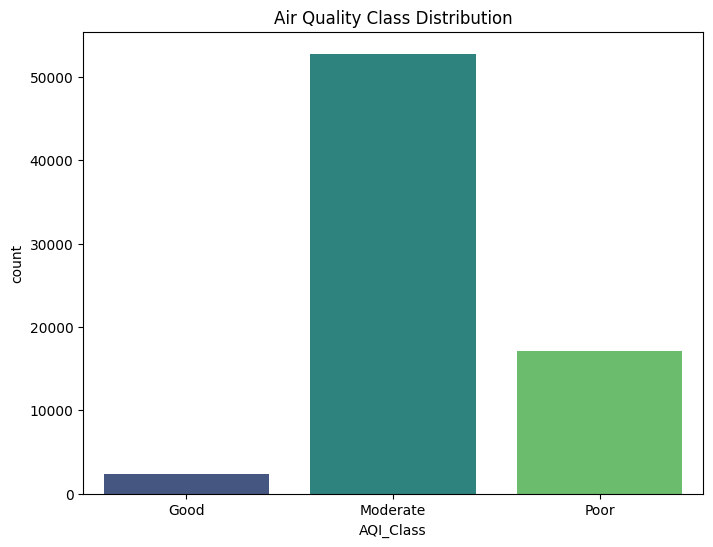

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Class', data=df, palette='viridis', order=['Good', 'Moderate', 'Poor'])
plt.title('Air Quality Class Distribution')
plt.show()

In [16]:
df=df.drop(columns=['pm2_5', 'time', 'day_of_week'])

In [17]:
df.head()

,pm10,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class,year,is_weekend
0,54.2,1.8,11.8,63,15.5,0.0,Moderate,2018,0
1,46.5,1.9,11.4,63,15.7,0.0,Good,2018,0
2,34.6,1.6,11.6,61,16.1,0.0,Good,2018,0
3,28.8,2.3,11.9,62,18.2,0.0,Moderate,2018,0
4,48.8,11.6,11.7,68,18.1,0.0,Poor,2018,0


# Data Preprocessing and Class Balancing (SMOTE)

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Label Encoding for the Target (Convert Good/Moderate/Poor to numerical values)
le = LabelEncoder()
df['AQI_Class'] = le.fit_transform(df['AQI_Class'])

# 2. Define Features (X) and Target (y)
X = df.drop(columns=['AQI_Class'])
y = df['AQI_Class']

# 3. Split the data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Standardize features by removing the mean and scaling to unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Handle Class Imbalance using SMOTE (Oversampling the minority classes)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Data Preprocessing Completed Successfully!")
print(f"Training set shape after SMOTE: {X_train_res.shape}")

Data Preprocessing Completed Successfully!
Training set shape after SMOTE: (126726, 8)


# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 1. Initialize and train the Logistic Regression model
# We use max_iter=1000 to ensure convergence on the resampled data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000, random_state=42)

In [20]:
# 2. Make predictions on the scaled test set
y_pred_lr = lr_model.predict(X_test_scaled)

In [21]:
# 3. Calculate Accuracies
lr_train_acc = lr_model.score(X_train_res, y_train_res)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

In [22]:
# 4. Print Metrics
print("--- Logistic Regression ---")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Testing Accuracy: {lr_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

--- Logistic Regression ---
Training Accuracy: 0.8831
Testing Accuracy: 0.8289

Classification Report:
              precision    recall  f1-score   support

        Good       0.30      0.91      0.45       476
    Moderate       0.95      0.81      0.87     10553
        Poor       0.75      0.89      0.81      3434

    accuracy                           0.83     14463
   macro avg       0.67      0.87      0.71     14463
weighted avg       0.88      0.83      0.84     14463



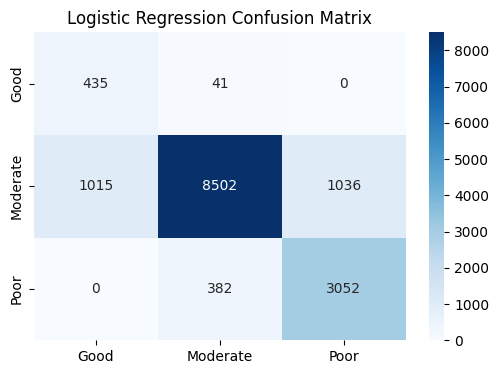

In [23]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
# 1. Initialize and train the k-NN model
# Setting n_neighbors=5 is a standard starting point for classification
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train_res, y_train_res)

KNeighborsClassifier(n_neighbors=10)

In [25]:
# 2. Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

In [26]:
# 3. Calculate Accuracies
knn_train_acc = knn_model.score(X_train_res, y_train_res)
knn_test_acc = knn_model.score(X_test_scaled, y_test)

In [27]:
# 4. Print Metrics
print("--- k-Nearest Neighbors ---")
print(f"Training Accuracy: {knn_train_acc:.4f}")
print(f"Testing Accuracy: {knn_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

--- k-Nearest Neighbors ---
Training Accuracy: 0.9445
Testing Accuracy: 0.8479

Classification Report:
              precision    recall  f1-score   support

        Good       0.31      0.86      0.45       476
    Moderate       0.96      0.83      0.89     10553
        Poor       0.78      0.90      0.83      3434

    accuracy                           0.85     14463
   macro avg       0.68      0.86      0.73     14463
weighted avg       0.89      0.85      0.86     14463



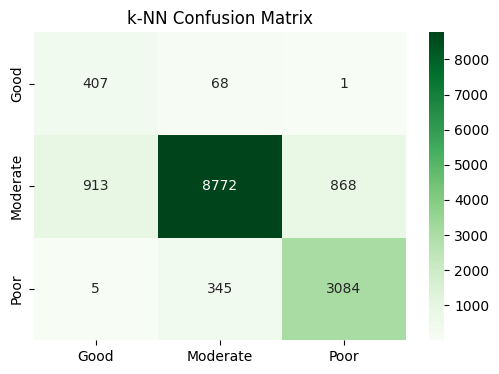

In [28]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('k-NN Confusion Matrix')
plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC

# 1. Initialize and train the SVM model
# Using RBF kernel to handle potential non-linear relationships
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_res, y_train_res)

In [ ]:
# 2. Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
svm_train_acc = svm_model.score(X_train_res, y_train_res)
svm_test_acc = svm_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Support Vector Machine ---")
print(f"Training Accuracy: {svm_train_acc:.4f}")
print(f"Testing Accuracy: {svm_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM Confusion Matrix')
plt.show()

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 1. Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train_res, y_train_res)

In [ ]:
# 2. Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
dt_train_acc = dt_model.score(X_train_res, y_train_res)
dt_test_acc = dt_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Decision Tree ---")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Testing Accuracy: {dt_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest Classifier
# n_estimators=100: Using 100 different decision trees to build the forest
# random_state=42: Ensuring reproducibility of results
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=10, random_state=42)

In [ ]:
# 2. Train the model using the resampled (SMOTE) training data
rf_model.fit(X_train_res, y_train_res)

In [ ]:
# 3. Calculate Accuracies
y_pred_rf = rf_model.predict(X_test_scaled)
rf_train_acc = rf_model.score(X_train_res, y_train_res)
rf_test_acc = rf_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Random Forest Classifier ---")
print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Testing Accuracy: {rf_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.show()

# Stacking Ensemble


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Define the Base Learners (The 6 models we trained earlier)
# We group our diverse models to act as "consultants"
# Note: probability=True is required for SVM to work within a Stacking Classifier
base_models = [
    ('lr', lr_model),                                     # Logistic Regression (Statistical Baseline)
    ('knn', knn_model),                                   # k-Nearest Neighbors (Distance-based)
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)), # SVM (Boundary-based)
    ('dt', dt_model),                                     # Decision Tree (Rule-based)
    ('rf', rf_model)                                      # Random Forest (Ensemble-based)
]



In [ ]:
# 2. Initialize and Train Stacking
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=1
)
stacking_clf.fit(X_train_res, y_train_res)

In [ ]:
# 3. Make predictions
y_pred_stack = stacking_clf.predict(X_test_scaled)

In [ ]:
# 4. Calculate Accuracies
stack_train_acc = stacking_clf.score(X_train_res, y_train_res)
stack_test_acc = stacking_clf.score(X_test_scaled, y_test)

In [ ]:
# 5. Print Metrics
print("--- Final Stacking Ensemble ---")
print(f"Training Accuracy: {stack_train_acc:.4f}")
print(f"Testing Accuracy: {stack_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

In [ ]:
# 6. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='magma',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Ensemble Confusion Matrix')
plt.show()

In [ ]:
# =================================================================
# PRINT PRE-CALCULATED ACCURACIES DIRECTLY
# =================================================================

# Create a dictionary using your already executed and saved variables
accuracy_summary = {
    "Logistic Regression": (lr_train_acc, lr_test_acc),
    "k-Nearest Neighbors": (knn_train_acc, knn_test_acc),
    "Support Vector Machine": (svm_train_acc, svm_test_acc),
    "Decision Tree": (dt_train_acc, dt_test_acc),
    "Random Forest": (rf_train_acc, rf_test_acc),
    "Final Stacking Ensemble": (stack_train_acc, stack_test_acc)
}

# Print the comparison table headers
print("=" * 65)
print(f"{'Model Name':<25} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("=" * 65)

# Loop through the summary dictionary and display the scores directly
for model_name, (train_acc, test_acc) in accuracy_summary.items():
    print(f"{model_name:<25} | {train_acc:>14.4f} | {test_acc:>14.4f}")

print("=" * 65)

In [ ]:
!pip install streamlit pyngrok imbalanced-learn -q

In [ ]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# ============================================
# PAGE CONFIG
# ============================================

st.set_page_config(
    page_title="Air Quality Dashboard",
    page_icon="🌍",
    layout="wide"
)

# ============================================
# CUSTOM CSS
# ============================================

st.markdown("""
<style>

.stApp {
    background: linear-gradient(to right, #0f172a, #1e293b);
    color: white;
}

h1,h2,h3,h4,h5 {
    color: white !important;
}

.metric-card {
    background-color: #1e293b;
    padding: 20px;
    border-radius: 20px;
    text-align: center;
    color: white;
    box-shadow: 0px 4px 15px rgba(0,0,0,0.3);
}

.block-container {
    padding-top: 2rem;
}

</style>
""", unsafe_allow_html=True)

# ============================================
# TITLE
# ============================================

st.title("🌍 Air Quality Prediction Dashboard")
st.markdown("### Machine Learning Project")

# ============================================
# LOAD DATA
# ============================================

@st.cache_data
def load_data():
    return pd.read_csv("air_quality_weather_data.csv")

try:
    df = load_data()

except:
    uploaded_file = st.file_uploader(
        "Upload your dataset",
        type=["csv"]
    )

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)

    else:
        st.stop()

# ============================================
# DATA CLEANING
# ============================================

df = df.drop_duplicates()

def get_aqi_class(pm25):

    if pm25 <= 12:
        return "Good"

    elif pm25 <= 35.4:
        return "Moderate"

    else:
        return "Poor"

df["AQI_Class"] = df["pm2_5"].apply(get_aqi_class)

# ============================================
# FEATURE ENGINEERING
# ============================================

if "time" in df.columns:

    df["time"] = pd.to_datetime(df["time"])

    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    df["hour"] = df["time"].dt.hour

# ============================================
# SIDEBAR
# ============================================

st.sidebar.title("📌 Navigation")

page = st.sidebar.radio(
    "Choose Page",
    [
        "🏠 Home",
        "📊 Dataset",
        "📈 Visualizations",
        "🤖 Model Comparison",
        "🔮 Prediction"
    ]
)

# ============================================
# HOME PAGE
# ============================================

if page == "🏠 Home":

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown(f"""
        <div class="metric-card">
            <h2>{len(df)}</h2>
            <p>Total Records</p>
        </div>
        """, unsafe_allow_html=True)

    with col2:
        st.markdown(f"""
        <div class="metric-card">
            <h2>{df.shape[1]}</h2>
            <p>Total Features</p>
        </div>
        """, unsafe_allow_html=True)

    with col3:
        st.markdown(f"""
        <div class="metric-card">
            <h2>{df['AQI_Class'].nunique()}</h2>
            <p>AQI Classes</p>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")

    st.subheader("📖 About Project")

    st.write("""
    This dashboard predicts Air Quality using Machine Learning.

    Models used:
    - Logistic Regression
    - KNN
    - SVM
    - Decision Tree

    The project analyses pollution and weather features.
    """)

# ============================================
# DATASET PAGE
# ============================================

elif page == "📊 Dataset":

    st.subheader("📊 Dataset Preview")

    st.dataframe(df.head(20), use_container_width=True)

    st.markdown("---")

    st.subheader("📌 Dataset Shape")

    st.write(df.shape)

    st.subheader("📌 Missing Values")

    st.write(df.isnull().sum())

# ============================================
# VISUALIZATIONS PAGE
# ============================================

elif page == "📈 Visualizations":

    st.subheader("📈 Correlation Heatmap")

    numeric_df = df.select_dtypes(include=np.number)

    fig, ax = plt.subplots(figsize=(12,6))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        ax=ax
    )

    st.pyplot(fig)

    st.markdown("---")

    st.subheader("🌍 AQI Distribution")

    fig2, ax2 = plt.subplots(figsize=(8,5))

    sns.countplot(
        x="AQI_Class",
        data=df,
        palette="viridis",
        ax=ax2
    )

    st.pyplot(fig2)

# ============================================
# MODEL COMPARISON
# ============================================

elif page == "🤖 Model Comparison":

    st.subheader("🤖 Compare ML Models")

    X = df.drop(columns=["AQI_Class"])

    if "time" in X.columns:
        X = X.drop(columns=["time"])

    X = X.select_dtypes(include=np.number)

    y = df["AQI_Class"]

    le = LabelEncoder()
    y = le.fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=42
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(),
        "Decision Tree": DecisionTreeClassifier()
    }

    results = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)

        results[name] = acc

    results_df = pd.DataFrame({
        "Model": results.keys(),
        "Accuracy": results.values()
    })

    st.dataframe(results_df, use_container_width=True)

    fig3, ax3 = plt.subplots(figsize=(8,5))

    sns.barplot(
        x="Model",
        y="Accuracy",
        data=results_df,
        palette="magma",
        ax=ax3
    )

    plt.ylim(0,1)

    st.pyplot(fig3)

# ============================================
# PREDICTION PAGE
# ============================================

elif page == "🔮 Prediction":

    st.subheader("🔮 Predict AQI")

    pm25 = st.slider("PM2.5", 0.0, 300.0, 20.0)

    pm10 = st.slider("PM10", 0.0, 300.0, 50.0)

    temp = st.slider("Temperature", -10.0, 50.0, 25.0)

    humidity = st.slider("Humidity", 0.0, 100.0, 60.0)

    wind = st.slider("Wind Speed", 0.0, 50.0, 10.0)

    if st.button("Predict Air Quality"):

        if pm25 <= 12:
            prediction = "🟢 Good"

        elif pm25 <= 35.4:
            prediction = "🟡 Moderate"

        else:
            prediction = "🔴 Poor"

        st.success(f"Predicted AQI: {prediction}")

        st.metric("PM2.5", pm25)
        st.metric("Temperature", temp)
        st.metric("Humidity", humidity)

# ============================================
# FOOTER
# ============================================

st.markdown("---")

st.markdown(
    "<center>Made with ❤️ using Streamlit</center>",
    unsafe_allow_html=True
)

'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('app.py created successfully!')

In [ ]:
from pyngrok import ngrok

# Replace "YOUR_NGROK_AUTHTOKEN" with your actual authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3Dxoy00L8GJ9R1ks6vj2uv2UOrH_2k4uLcwCg11mM6bicH28n")

In [ ]:
from pyngrok import ngrok
import threading
import subprocess
import time

ngrok.kill()
time.sleep(2) # Added a short delay to ensure ngrok processes are fully terminated

def run_streamlit():
    subprocess.Popen([
        'streamlit',
        'run',
        'app.py',
        '--server.port=8501'
    ])

thread = threading.Thread(target=run_streamlit)
thread.start()

time.sleep(8)

public_url = ngrok.connect(8501)

print("Your Streamlit App URL:")
print(public_url)